# Logistic Regression

In this notebook we expand on the linear regression topic from previous notebook and show how we can use linear models for classification tasks. We will walk through:

1. Load a scikit-learn dataset with **multinomial/multi-class features**.
2. Using **linear regression** in combination with a **step function** (linear decision rules) to undertake a classification task.
3. Using **logistic regression** for the same task.
4. Calculating **class probability** and **accuracy** for linear classification models.
5. Compare the performance of these two models.
6. Use **regularization** strategies with logistic regression.
7. Plotting **decision boundaries for linear classification**.

In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import softmax
from sklearn import datasets
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 2026
np.random.seed(SEED)


## Data Preprocessing

We will be using **Iris** dataset which is used for multinomial multiclass classifications.

- **Target**: 3 flower species (3 classes)
- **Features**: 4 measurements

We load our data and conduct the following data preprocessing:

- We first transform features to **DataFrame**.
- Since our target is 3 classes (0, 1, 2) for each flower we need to employ **one-hot-encoding**.
- After the encoding we transform the target into a DataFrame as well.
- We use StandardScaler to **standardize** our features. This is not strictly required for LinearRegression but recommended especially for LogisticRegression.


In [2]:
iris = datasets.load_iris()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(iris.data)
X = pd.DataFrame(X_scaled, columns=iris.feature_names)
y = iris.target

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


## Linear Regression for Classification (Step Function)

Since we have a multinomial classification we first need to apply an encoding scheme to create additional columns each containing only 0/1 values for the target. We use **OneHotEncoding**.

Note that using `LinearRegression` built-in uses a **closed-form computation**.

Also note that values in Y_hat values **are not probabilities**.


In [3]:
# OneHotEncoding is needed when using Linear Regression
enc = OneHotEncoder(sparse_output=False)
encoded = enc.fit_transform(iris.target.reshape(-1, 1))
colnames = ["cat_" + c for c in iris.target_names]
Y = pd.DataFrame(encoded, columns=colnames)

Y.head()

,cat_setosa,cat_versicolor,cat_virginica
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


In [4]:
lr = LinearRegression(fit_intercept=True)
lr.fit(X, Y)

Y_hat = lr.predict(X)
# The Y_hat values are regression coefficients and not probabilities
# You can test that by summing each row up (should add to 1 if probability value)
print(f"Does abs of Y_hat rows sum to 1? {np.allclose(np.abs(Y_hat).sum(axis=1), 1)}")

# If we want to compute log-loss we must convert them to pseudo-probabilities using softmax
pseudo_proba = softmax(Y_hat, axis=1)
print(
    f"Do pseudo_proba rows sum to 1? {np.allclose(np.abs(pseudo_proba).sum(axis=1), 1)}"
)

loss = log_loss(y, pseudo_proba)
print(f"Log-loss = {loss:.3f}")

y_hat = np.argmax(Y_hat, axis=1)
acc = accuracy_score(y, y_hat)
print(f"Accuracy = {acc: .3f}")

Does abs of Y_hat rows sum to 1? False
Do pseudo_proba rows sum to 1? True
Log-loss = 0.769
Accuracy =  0.847


Note that for multinomial classification, we have $c \times p$ weights (coefficients) and $c$ biases (intercepts) where $c = n_{classes}$ and $p = n_{features}$

In [5]:
print(f"Coefficients:\n{lr.coef_}\n")
print(f"Biases:\n{lr.intercept_}")

Coefficients:
[[ 0.05449445  0.10549578 -0.39526264 -0.04366161]
 [-0.01663286 -0.19358059  0.3882463  -0.37552108]
 [-0.03786159  0.08808481  0.00701635  0.41918269]]

Biases:
[0.33333333 0.33333333 0.33333333]


## Logistic Regression for Classification


Note that this is an **iterative approach** unlike when using built-in `LinearRegression` that just uses a closed-form computation.

Also note that your fitted object now can directly compute **probability values** using .predict_probab()


In [6]:
lr = LogisticRegression(
    penalty=None, fit_intercept=True, random_state=SEED, max_iter=100
)
lr.fit(X, y)

probs = lr.predict_proba(X)
print(f"Do probs rows sum to 1? {np.allclose(np.abs(probs).sum(axis=1), 1)}")
loss = log_loss(y, probs)

print(f"Log-loss = {loss:.3f}")
acc = lr.score(X, y)  # You could also use accuracy_score(y, y_hat)
print(f"Accuracy = {acc: .3f}\n")

print(f"Coefficients:\n{lr.coef_}\n")
print(f"Biases:\n{lr.intercept_}")

Do probs rows sum to 1? True
Log-loss = 0.040
Accuracy =  0.987

Coefficients:
[[-5.49540457  4.00607389 -9.03369921 -8.20371202]
 [ 3.75962335 -0.54397735 -3.81148198 -2.88632939]
 [ 1.73578122 -3.46209655 12.84518118 11.0900414 ]]

Biases:
[-1.86673606 11.03981771 -9.17308165]


Accuracy is pretty impressive compared with using linear regression!


## Regularization

In above use of logistic regression we did not use any regularization.

To showcase the effect of regularization we will set aside a **test split** for model evaluation. We will fit two models one without and one with regularization and then compare their training and test accuracy metrics with each other.


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.5, random_state=SEED, shuffle=True, stratify=y
)
# For this particular demonstration we're not standardizing data.

In [34]:
solver = "lbfgs"

unregulated = LogisticRegression(
    penalty=None, fit_intercept=True, random_state=SEED, solver=solver, max_iter=1_000
)
unregulated.fit(X_train, y_train)
unregulated_train_acc = unregulated.score(X_train, y_train)
unregulated_test_acc = unregulated.score(X_test, y_test)
print("Unregulated Model:")
print(f"    Train Accuracy:     {unregulated_train_acc:.3f}")
print(f"    Test Accuracy:      {unregulated_test_acc:.3f}")

# C parameter controls the strength of regularization
regulated = LogisticRegression(
    penalty="l2",
    C=1.0,
    fit_intercept=True,
    random_state=SEED,
    solver=solver,
    max_iter=1_000,
)
regulated.fit(X_train, y_train)
regulated_train_acc = regulated.score(X_train, y_train)
regulated_test_acc = regulated.score(X_test, y_test)
print("Regulated Model:")
print(f"    Train Accuracy:     {regulated_train_acc:.3f}")
print(f"    Test Accuracy:      {regulated_test_acc:.3f}")

Unregulated Model:
    Train Accuracy:     1.000
    Test Accuracy:      0.947
Regulated Model:
    Train Accuracy:     0.973
    Test Accuracy:      0.960


In Lecture we mentioned that **L1 penalty term** with sufficiently small C is equivalent to **feature selection**. Let's see this in action.

You will see that some of the coefficients for some classes are completely 0 which means these features are effectively selected out for those classes.


In [13]:
lr = LogisticRegression(
    penalty="l1",
    C=0.3,
    fit_intercept=True,
    random_state=SEED,
    solver="saga",
    max_iter=5_000,
)

lr.fit(X, y)

print(f"Overall training accuracy = {lr.score(X, y):.3f}\n")

for i, c in enumerate(iris.target_names):
    print(f"For class {c.upper()}")
    for j, f in enumerate(iris.feature_names):
        print(f"    Feature {f}: Coefficient {lr.coef_[i,j]:.2f}")

print("\nHowever the coefficients for unregulated model are all non-zero:\n")
print(unregulated.coef_.round(2))

Overall training accuracy = 0.960

For class SETOSA
    Feature sepal length (cm): Coefficient 0.00
    Feature sepal width (cm): Coefficient 0.57
    Feature petal length (cm): Coefficient -3.38
    Feature petal width (cm): Coefficient 0.00
For class VERSICOLOR
    Feature sepal length (cm): Coefficient 0.00
    Feature sepal width (cm): Coefficient 0.00
    Feature petal length (cm): Coefficient 0.00
    Feature petal width (cm): Coefficient 0.00
For class VIRGINICA
    Feature sepal length (cm): Coefficient 0.00
    Feature sepal width (cm): Coefficient 0.00
    Feature petal length (cm): Coefficient 1.34
    Feature petal width (cm): Coefficient 3.41

However the coefficients for unregulated model are all non-zero:

[[-36.24  20.55 -57.72 -52.03]
 [ 25.17  -5.35 -16.62 -42.58]
 [ 11.06 -15.2   74.35  94.61]]


## Decision Boundaries (2D)

We can plot the decision boundaries for different regularization strengths.
- Note that these boundaries are linear. Compare them to the boundaries for KNN and Decision Trees.
- Lower C values means higher regularization.
- A more regularized model misclassifies more on training set (but will generalize better to unseen data). This is **bias-variance tradeoff** in action.

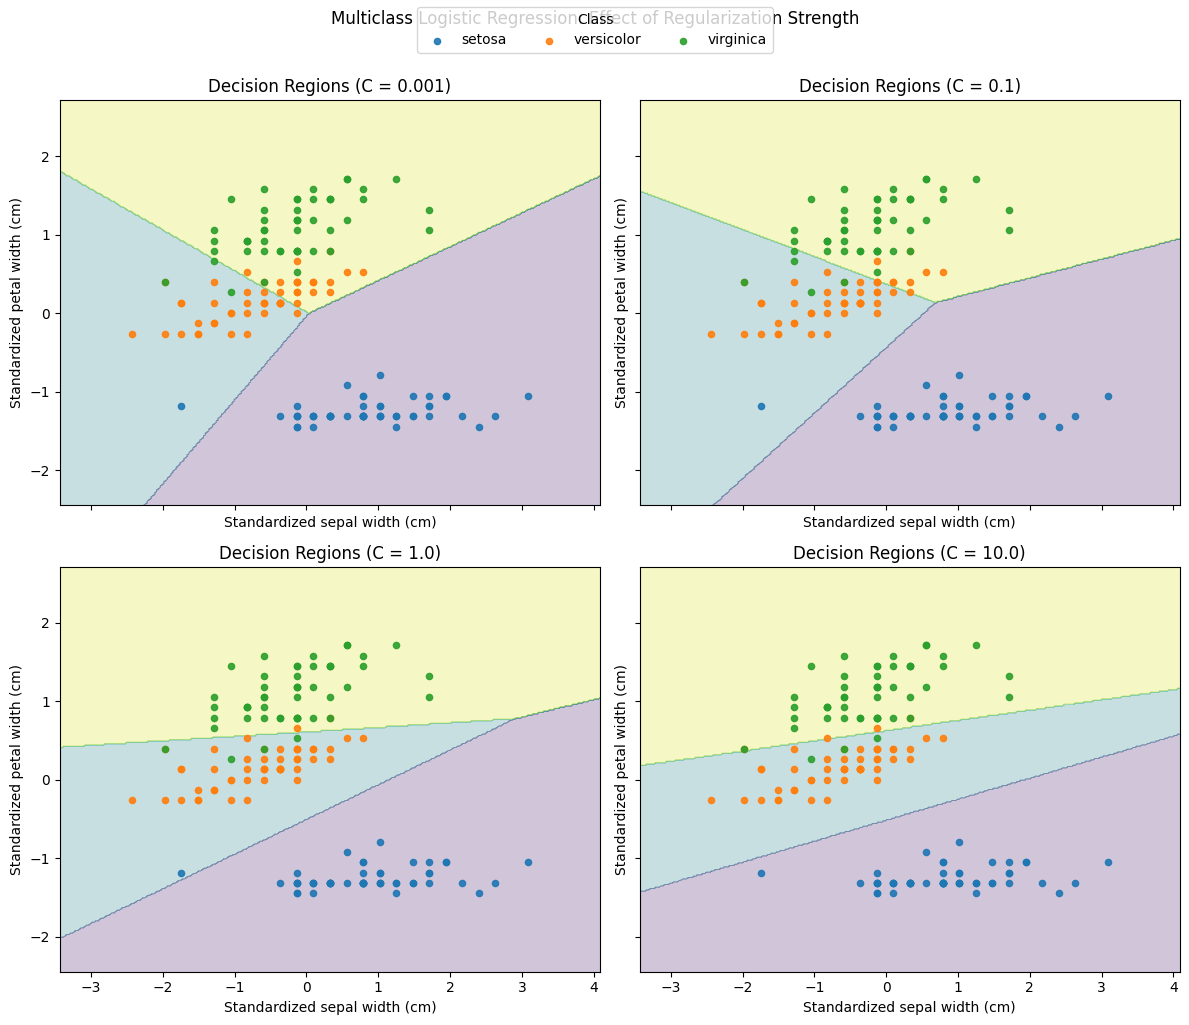

In [14]:
# ----- assumes you already have: X2, y_iris, iris_target_names, iris_feature_names, f1, f2 -----
f1, f2 = 1, 3
X2 = X.iloc[:, [f1, f2]].to_numpy()

# Mesh grid for decision regions
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Different regularization strengths to compare
C_values = [0.001, 0.1, 1.0, 10.0]  # small C = strong reg, large C = weak reg

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, C in zip(axes, C_values):
    model = LogisticRegression(solver="lbfgs", C=C, max_iter=500)
    model.fit(X2, y)

    Z = model.predict(grid).reshape(xx.shape)

    # Decision regions
    ax.contourf(xx, yy, Z, alpha=0.25)

    # Points per class (legend handled once later)
    for cls, name in enumerate(iris.target_names):
        mask = y == cls
        ax.scatter(X2[mask, 0], X2[mask, 1], label=name, alpha=0.9, s=20)

    ax.set_title(f"Decision Regions (C = {C})")
    ax.set_xlabel(f"Standardized {iris.feature_names[f1]}")
    ax.set_ylabel(f"Standardized {iris.feature_names[f2]}")

# Build one shared legend (avoid duplicates)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, title="Class", loc="upper center", ncol=len(iris.target_names)
)

fig.suptitle(
    "Multiclass Logistic Regression: Effect of Regularization Strength", y=1.02
)
plt.tight_layout()
plt.show()
